# 第五章：LLM 工程实践

前四章建立了从感知机到大语言模型的理论基础。本章转向工程实践——在实际产品中把 LLM 用好。

核心问题：**预训练模型的参数是固定的，怎么让它回答关于你自己数据的问题？怎么让它使用外部工具完成复杂任务？**

本章依次介绍两个最主流的落地路线：
- **RAG（检索增强生成）**：用向量检索把外部知识注入 prompt，不改模型参数
- **Agent 开发**：让 LLM 具备规划和调用工具的能力，完成多步骤任务

## 目录

| 章节 | 内容 |
|------|------|
| **5.1 RAG 系统设计** | 为什么需要 RAG、完整流水线（分块→向量化→检索→生成）、向量数据库选型 |
| **5.2 RAG 进阶** | 重排（Reranking）、混合检索、评估指标（RAGAS）、常见失效模式 |
| **5.3 Agent 基础** | ReAct 框架、工具调用（Function Calling）、规划与执行 |
| **5.4 Agent 进阶** | 记忆系统（短期/长期）、多 Agent 协作、常用框架对比（LangChain / LlamaIndex / AutoGen）|
| **5.5 工程实战** | 端到端 RAG + Agent 系统搭建，含可运行代码 |

In [1]:
import math
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

matplotlib.rcParams['font.family'] = ['PingFang SC', 'Heiti TC', 'Arial Unicode MS', 'DejaVu Sans']
matplotlib.rcParams['axes.unicode_minus'] = False

## 5.1 RAG 系统设计

### 为什么需要 RAG？

LLM 有两个根本性限制：

**① 知识截止（Knowledge Cutoff）**：预训练数据有截止日期，模型不知道训练后发生的事。  
**② 私有数据盲区**：企业内部文档、私有代码库、个人笔记——这些从未出现在训练数据里，模型无从回答。

**幻觉（Hallucination）** 是这两个问题的直接后果：当模型不知道答案时，它不会说"不知道"，而是编造一个听起来合理的回答。

---

### 三种解决思路对比

| 方案 | 做法 | 优点 | 缺点 |
|------|------|------|------|
| **微调** | 把私有数据训练进模型权重 | 知识"内化"，无需检索 | 训练成本高；知识更新需重训；容易过拟合 |
| **长上下文** | 把所有文档塞进 prompt | 简单直接 | context window 有上限（即使 128k 也装不下企业文档库）；成本随长度平方级增加 |
| **RAG** | 检索相关片段，注入 prompt | 知识可实时更新；成本可控；可溯源 | 检索质量决定回答质量；流水线复杂 |

**RAG（Retrieval-Augmented Generation）** 的核心思路：

```
用户问题
    │
    ▼ 检索
从外部知识库中找出最相关的几段文字
    │
    ▼ 注入
把这几段文字 + 用户问题一起放进 prompt
    │
    ▼ 生成
LLM 根据提供的文字回答问题
```

模型的权重一字不改，改变的只是"给模型看什么"。

---

### RAG 完整流水线

RAG 分为两个阶段：**离线索引** 和 **在线查询**。

```
═══════════════════ 离线索引阶段（一次性准备）═══════════════════
                                                                 
 原始文档                                                         
（PDF/HTML/MD）                                                   
      │                                                           
      ▼ 步骤 1：解析                                              
  纯文本提取                                                      
      │                                                           
      ▼ 步骤 2：分块（Chunking）                                  
  [块₁] [块₂] [块₃] ... [块ₙ]                                   
      │                                                           
      ▼ 步骤 3：向量化（Embedding）                               
  [v₁]  [v₂]  [v₃]  ... [vₙ]  ← 每块变成一个高维向量            
      │                                                           
      ▼ 步骤 4：存入向量数据库                                     
  ┌─────────────────────────────┐                                 
  │  向量数据库（如 Faiss/Chroma）│                                
  └─────────────────────────────┘                                 

═══════════════════ 在线查询阶段（每次问答）══════════════════════

  用户提问："XXX 是什么？"
      │
      ▼ 步骤 5：问题向量化
  query_vector
      │
      ▼ 步骤 6：相似度检索（Top-K）
  [最相关块₂] [次相关块₇] [块₁₄] ← 取最相似的 K 个块
      │
      ▼ 步骤 7：构造 Prompt
  ┌──────────────────────────────────────────┐
  │ 你是一个问答助手。根据以下资料回答问题。  │
  │                                          │
  │ 资料 1：[块₂ 的文字内容]                │
  │ 资料 2：[块₇ 的文字内容]                │
  │ 资料 3：[块₁₄ 的文字内容]              │
  │                                          │
  │ 问题：XXX 是什么？                       │
  └──────────────────────────────────────────┘
      │
      ▼ 步骤 8：LLM 生成回答（含引用）
  "根据资料 1，XXX 是..."
```

---

### 步骤 2：分块策略（Chunking）

分块是 RAG 中最容易被忽视、影响最大的步骤之一。

**为什么不直接用整篇文档？**
- 整篇文档可能 10,000 词，embedding 后变成一个向量——丢失了局部语义
- 注入 prompt 时需要精确找到"相关段落"，不是整篇文章

**常见分块策略**：

```
① 固定长度分块（最简单）
  每 512 个 token 切一刀，相邻块有 50 token 的重叠（overlap）
  优点：实现简单
  缺点：可能从句子中间切断

② 句子/段落级分块（推荐）
  按自然段落或句号分块，保持语义完整性
  通常每块 200-500 词

③ 递归分块（LangChain 默认）
  优先按段落→句子→词级别切割，保持结构完整

④ 语义分块（高级）
  用 embedding 计算相邻句子的相似度，在相似度突变处切块
  效果好，计算成本高
```

**分块大小的权衡**：
- **太小**：单个块没有足够上下文，模型可能误解
- **太大**：检索精度下降，而且 Top-K 召回的 token 总量上升，prompt 成本增加

---

### 步骤 3：向量化（Embedding）

将文本映射到高维向量空间，使"语义相似 ↔ 向量距离近"。

**常用 Embedding 模型**：

| 模型 | 维度 | 特点 |
|------|------|------|
| `text-embedding-3-small`（OpenAI） | 1536 | API 调用，效果好 |
| `text-embedding-3-large`（OpenAI） | 3072 | 更强，成本更高 |
| `bge-m3`（BAAI，开源） | 1024 | 多语言，中文效果优秀 |
| `bge-large-zh-v1.5`（BAAI，开源） | 1024 | 中文专用 |
| `sentence-transformers/all-MiniLM-L6-v2`（开源） | 384 | 轻量，速度快 |

**重要原则**：查询（query）和文档（document）必须用**同一个 embedding 模型**，否则它们在不同的向量空间里，相似度计算没有意义。

---

### 步骤 6：相似度检索

向量化后，相似度检索的核心是在向量空间里找最近邻。

**余弦相似度**（最常用）：

$$\text{similarity}(q, d) = \frac{q \cdot d}{\|q\| \cdot \|d\|}$$

值域 $[-1, 1]$，越接近 1 表示语义越相似。

**检索方式**：
- **精确搜索（暴力检索）**：对所有向量逐一计算相似度，$O(n)$。文档少时够用。
- **近似最近邻（ANN）**：HNSW、IVF 等索引结构，牺牲少量精度换取 $O(\log n)$ 速度，百万级文档时必用。

---

### 向量数据库选型

| 工具 | 类型 | 适用场景 |
|------|------|----------|
| **Faiss**（Meta，开源） | 库（非服务） | 本地实验，高性能 ANN |
| **Chroma** | 本地服务 | 快速原型，本地开发 |
| **Weaviate** | 向量数据库 | 中等规模，内置混合检索 |
| **Pinecone** | 托管云服务 | 快速上线，免运维 |
| **Milvus** | 开源分布式 | 大规模生产，亿级向量 |
| **Qdrant** | 开源，Rust 实现 | 高性能，支持过滤 |

**选型建议**：
- 原型阶段：Chroma（本地零配置）
- 生产小规模（< 1000万向量）：Qdrant 或 Weaviate
- 大规模（> 1亿向量）：Milvus 或 Pinecone

findfont: Failed to find font weight bold, now using 600.
findfont: Failed to find font weight bold, now using 400.
findfont: Failed to find font weight bold, now using 400.


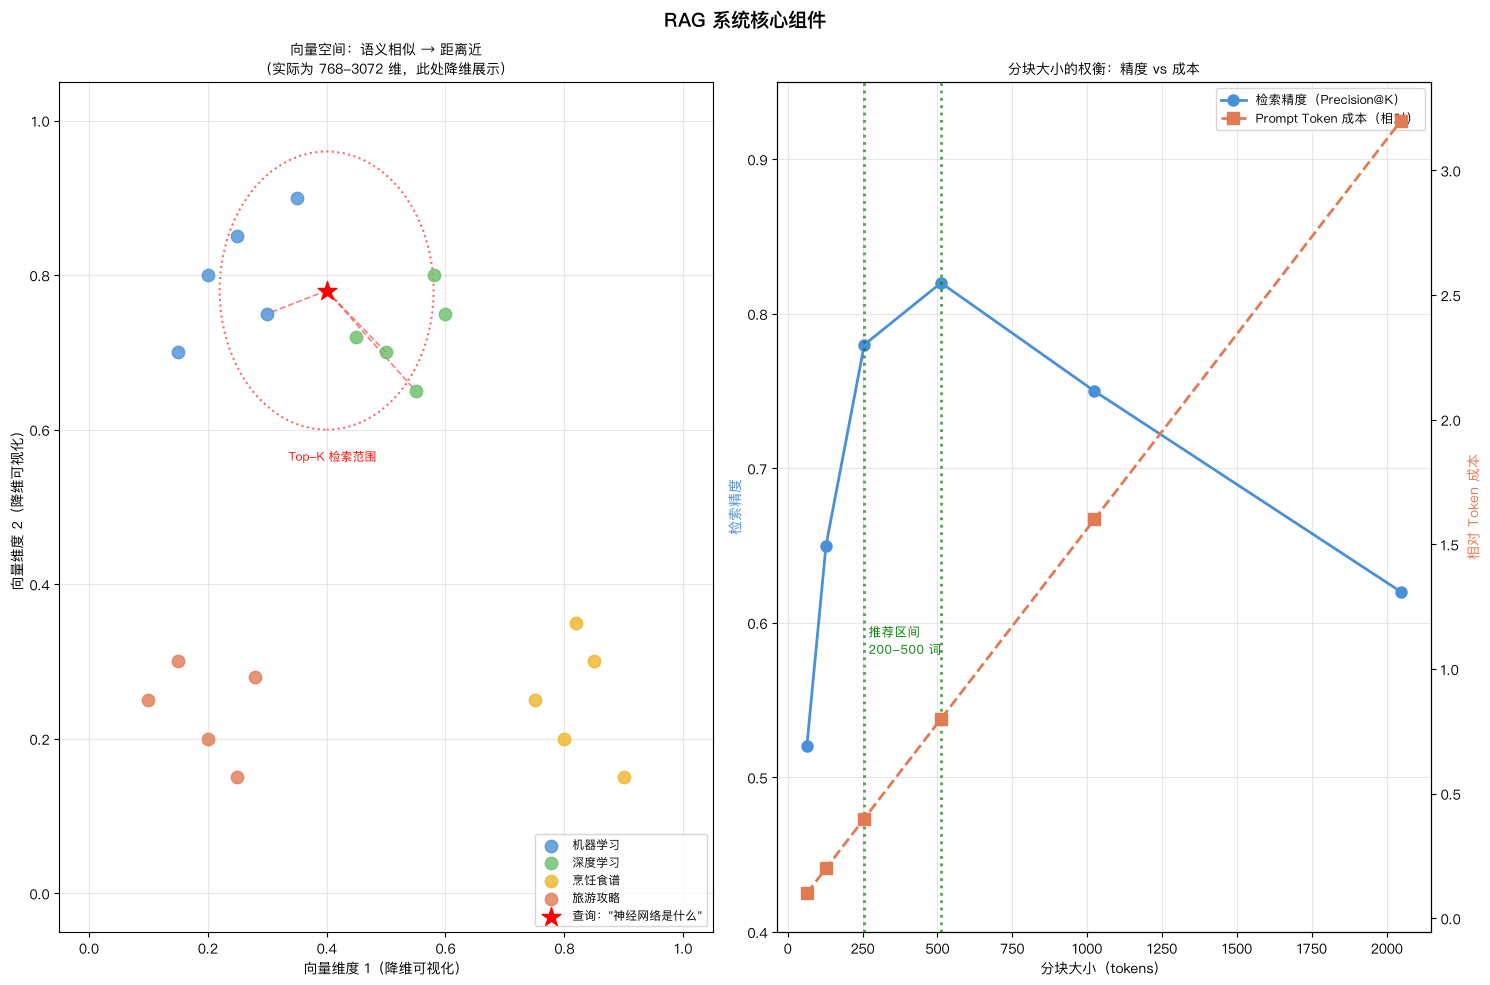

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

np.random.seed(42)
fig = plt.figure(figsize=(15, 10))
fig.suptitle('RAG 系统核心组件', fontsize=14, fontweight='bold')

# ── 左图：向量空间中的语义相似度 ──────────────────────────────────────────
ax1 = fig.add_subplot(1, 2, 1)

# 模拟 2D 向量空间（实际是 768/1024 维，这里降维展示）
topics = {
    '机器学习': (np.array([[0.2, 0.8], [0.3, 0.75], [0.25, 0.85],
                            [0.15, 0.7], [0.35, 0.9]]),  '#4a90d9'),
    '深度学习': (np.array([[0.5, 0.7], [0.6, 0.75], [0.55, 0.65],
                            [0.45, 0.72], [0.58, 0.8]]),  '#6abf69'),
    '烹饪食谱': (np.array([[0.8, 0.2], [0.85, 0.3], [0.75, 0.25],
                            [0.9, 0.15], [0.82, 0.35]]),  '#f0b429'),
    '旅游攻略': (np.array([[0.2, 0.2], [0.15, 0.3], [0.25, 0.15],
                            [0.1, 0.25], [0.28, 0.28]]),  '#e07b54'),
}

for topic, (points, color) in topics.items():
    ax1.scatter(points[:, 0], points[:, 1], c=color, s=80, alpha=0.8, label=topic, zorder=3)

# 查询向量
query = np.array([0.4, 0.78])
ax1.scatter(*query, c='red', s=200, marker='*', zorder=5, label='查询："神经网络是什么"')

# 画出到最近邻的距离
nn_points = np.array([[0.5, 0.7], [0.3, 0.75], [0.55, 0.65]])
for p in nn_points:
    ax1.plot([query[0], p[0]], [query[1], p[1]], 'r--', alpha=0.5, linewidth=1.2)

# Top-3 高亮圆
circle = plt.Circle(query, 0.18, fill=False, color='red', linestyle=':', linewidth=1.5, alpha=0.6)
ax1.add_patch(circle)
ax1.text(query[0] + 0.01, query[1] - 0.22, 'Top-K 检索范围', ha='center', fontsize=8.5, color='red')

ax1.set_xlim(-0.05, 1.05); ax1.set_ylim(-0.05, 1.05)
ax1.set_xlabel('向量维度 1（降维可视化）', fontsize=10)
ax1.set_ylabel('向量维度 2（降维可视化）', fontsize=10)
ax1.set_title('向量空间：语义相似 → 距离近\n（实际为 768-3072 维，此处降维展示）', fontsize=10)
ax1.legend(fontsize=8.5, loc='lower right')
ax1.grid(True, alpha=0.3)

# ── 右图：分块大小对检索效果的影响（示意） ────────────────────────────────
ax2 = fig.add_subplot(1, 2, 2)

chunk_sizes = [64, 128, 256, 512, 1024, 2048]
# 模拟：检索精度先升后降，成本随 chunk 大小单调上升
retrieval_precision = [0.52, 0.65, 0.78, 0.82, 0.75, 0.62]
prompt_token_cost   = [0.1,  0.2,  0.4,  0.8,  1.6,  3.2]   # 相对成本

ax2_right = ax2.twinx()

l1, = ax2.plot(chunk_sizes, retrieval_precision, 'o-', color='#4a90d9',
               linewidth=2, markersize=8, label='检索精度（Precision@K）')
l2, = ax2_right.plot(chunk_sizes, prompt_token_cost, 's--', color='#e07b54',
                     linewidth=2, markersize=8, label='Prompt Token 成本（相对）')

ax2.axvline(256, color='green', linestyle=':', linewidth=2, alpha=0.7)
ax2.text(270, 0.58, '推荐区间\n200-500 词', fontsize=9, color='green')
ax2.axvline(512, color='green', linestyle=':', linewidth=2, alpha=0.7)

ax2.set_xlabel('分块大小（tokens）', fontsize=10)
ax2.set_ylabel('检索精度', fontsize=10, color='#4a90d9')
ax2_right.set_ylabel('相对 Token 成本', fontsize=10, color='#e07b54')
ax2.set_title('分块大小的权衡：精度 vs 成本', fontsize=10)
ax2.set_ylim(0.4, 0.95)

lines = [l1, l2]
labels = [l.get_label() for l in lines]
ax2.legend(lines, labels, fontsize=9, loc='upper right')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 5.2 RAG 进阶

朴素 RAG 的问题：用 embedding 相似度直接检索 Top-K，然后塞进 prompt。这在 Demo 层面能跑，但生产环境里经常失效——检索回来的块不是真正有用的，或者遗漏了关键信息。

这一节介绍让 RAG 从"能用"变成"好用"的三个核心技术。

---

### 5.2.1 重排（Reranking）

**问题**：Embedding 相似度是一个粗粒度的语义相似度。两个句子向量接近，不代表一个能回答另一个问题。

**例子**：
```
查询：  "Python 中如何读取 JSON 文件？"

向量检索 Top-3 结果：
  块 A（相似度 0.92）："Python 是一种编程语言，广泛用于数据科学..."
                        ← 话题相关，但没回答问题
  块 B（相似度 0.89）："用 json.load(f) 打开文件即可读取..."
                        ← 这才是真正的答案！但排在第二
  块 C（相似度 0.87）："JSON 格式是一种轻量级的数据交换格式..."
                        ← 背景知识，不是答案
```

**Reranker（重排模型）**的做法：把查询和每个候选块**同时输入**一个 Cross-Encoder 模型，让它给每对 (query, chunk) 打一个精确的相关性分数，然后按这个分数重新排序。

```
                  向量检索（速度快，精度粗）
查询 ──────────────────────────────────────────▶ Top-50 候选块
                                                        │
                                              Reranker（精度高，但只看50个）
                                                        │
                                                        ▼
                                              重排后 Top-3 → 注入 Prompt
```

**两阶段检索**（工业标准）：
1. **召回（Recall）**：用向量检索快速从百万文档里拉出 50-100 个候选（速度优先）
2. **精排（Rerank）**：用 Cross-Encoder 对这 50-100 个精打细算，取前 3-5 个（精度优先）

**常用 Reranker 模型**：
- `bge-reranker-v2-m3`（BAAI，开源，多语言）
- `cohere-rerank-v3`（Cohere API）
- `cross-encoder/ms-marco-MiniLM-L6-v2`（开源，英文）

---

### 5.2.2 混合检索（Hybrid Search）

**问题**：纯向量检索（语义检索）擅长处理"同义词/概念匹配"，但对精确词汇（如产品型号、人名、代码关键字）反而表现差。

**例子**：
```
查询："GPT-4o-mini 的上下文窗口是多少？"

语义检索：会召回所有"关于 GPT 上下文"的文档（可能拉回旧版本信息）
关键词检索：直接匹配 "GPT-4o-mini" 这个字符串，精确度更高
```

**混合检索 = 向量检索 + 关键词检索（BM25）**

**BM25** 是一种经典的关键词相关性算法（比 TF-IDF 更精细），基于词频、文档长度归一化打分。

```
向量检索分数（语义）   BM25 分数（关键词）
      │                      │
      └─────────── 加权融合 ──┘
      score = α × semantic_score + (1-α) × bm25_score
                ↑
          通常 α = 0.5~0.7
```

**RRF（Reciprocal Rank Fusion）**：更常用的融合方式，不直接加分数（因为两者量纲不同），而是融合排名：

$$\text{RRF}(d) = \sum_{r \in R} \frac{1}{k + \text{rank}_r(d)}, \quad k = 60$$

其中 $r$ 遍历所有检索结果列表，$\text{rank}_r(d)$ 是文档 $d$ 在列表 $r$ 中的排名，$k=60$ 是平滑常数。文档在多个列表里都排名靠前，RRF 分数就高。

---

### 5.2.3 查询改写（Query Rewriting）

**问题**：用户的原始问题可能模糊、有歧义，或者表述方式和文档不匹配。

**几种改写策略**：

```
① HyDE（假设文档嵌入）
  让 LLM 先"假装"生成一段能回答这个问题的文档
  用这段假文档的 embedding 去检索（而不是问题的 embedding）
  
  用户问："量子计算机什么时候商业化？"
  HyDE 生成："量子计算机预计将在 2025-2030 年间开始商业化，目前
             IBM、Google 等公司已推出商用量子云服务..."
  ↑ 这段话的 embedding 比原始问题更接近知识库里的答案段落

② Multi-Query（多查询扩展）
  用 LLM 生成原始问题的多个改写版本，分别检索后合并去重
  
  "LoRA 怎么用？" → 同时检索：
    "LoRA fine-tuning 使用方法"
    "Low-Rank Adaptation 实现教程"
    "PEFT LoRA 代码示例"

③ Step-Back Prompting（退一步提问）
  把具体问题转化为更通用的背景问题，先检索背景知识
  
  "A100 GPU 微调 LLaMA-7B 需要多少显存？" 
  → 退一步："GPU 显存需求的计算方法是什么？"
```

---

### 5.2.4 RAG 评估指标（RAGAS 框架）

没有量化评估，RAG 优化就是盲人摸象。RAGAS 是目前最广泛使用的 RAG 评估框架，定义了四个核心指标：

| 指标 | 含义 | 检测的问题 |
|------|------|------------|
| **Faithfulness（忠实度）** | 回答中的每个陈述是否都有检索文档支撑 | 幻觉：模型编造了文档里没有的内容 |
| **Answer Relevancy（回答相关性）** | 回答是否真正回答了问题 | 废话：回答很长但没有直接回答 |
| **Context Precision（上下文精确度）** | 检索回来的文档中，有多少比例是真正有用的 | 检索噪声：拉回了很多不相关文档 |
| **Context Recall（上下文召回率）** | 参考答案中的信息，有多少比例能在检索文档中找到 | 检索遗漏：关键信息没被检索到 |

**RAGAS 的评估方式**：每个指标都用 LLM-as-Judge（让另一个 LLM 来打分），不需要人工标注。但这也意味着评分结果本身可能有噪声。

---

### 5.2.5 常见失效模式

| 失效类型 | 现象 | 根因 | 解法 |
|----------|------|------|------|
| **检索失败** | 模型说"文档中未找到相关信息"，但文档里其实有 | 分块破坏了语义；embedding 模型与文档语言不匹配 | 优化分块；换更好的 embedding 模型 |
| **幻觉混入** | 回答混合了文档内容和模型编造内容 | Prompt 没有严格要求只基于文档 | 加强 system prompt：Only answer based on the provided context |
| **信息截断** | 回答只用到了前几个检索块，忽略后面的 | LLM 的"迷失在中间"（Lost in the middle）效应——模型更关注 prompt 的开头和结尾 | 重排时把最相关的块放在首尾；减少 Top-K 数量 |
| **过时信息** | 检索到的是旧版文档 | 向量数据库没有及时更新 | 文档更新时触发重新索引；加时间戳过滤 |
| **跨文档推理失败** | 问题需要综合多个文档才能回答，但单块检索做不到 | 单块语义不完整 | 使用 GraphRAG（知识图谱 + RAG）；增大 chunk 窗口 |

## 5.3 Agent 基础：ReAct 与工具调用

### 从"问答"到"任务执行"

RAG 系统的能力边界：它能回答基于文档的问题，但做不了**多步骤任务**。

> 用户："帮我分析一下最近一个月的销售数据，画出趋势图，然后发邮件给老板。"

这个任务需要：查数据库 → 计算统计量 → 调用绘图工具 → 发送邮件。每一步的输入依赖上一步的输出，中间可能还需要根据结果做判断。这是 **Agent（智能体）** 要解决的问题。

---

### Agent 的定义

**Agent = LLM + 工具 + 循环**

```
┌─────────────────────────────────────────────────────────────┐
│                         Agent 循环                           │
│                                                              │
│  用户任务                                                     │
│      │                                                       │
│      ▼                                                       │
│  LLM 思考：                                                  │
│  "我需要先做 X，然后做 Y"                                     │
│      │                                                       │
│      ▼                                                       │
│  执行工具调用（如：查数据库）                                  │
│      │                                                       │
│      ▼                                                       │
│  工具返回结果                                                 │
│      │                                                       │
│      ▼                                                       │
│  LLM 根据结果再思考：                                         │
│  "结果显示 X，下一步应该 Y"                                   │
│      │                                                       │
│      ▼                                                       │
│  继续循环... 直到任务完成                                      │
└─────────────────────────────────────────────────────────────┘
```

---

### ReAct 框架（Reasoning + Acting）

ReAct（Yao et al., 2022）是目前最主流的 Agent 思维框架，核心思路是**让 LLM 交替进行"思考"和"行动"**，而不是直接跳到结论。

**一个例子**：

> 任务："苹果公司的市值目前是微软的几倍？"

**直接生成（会幻觉）**：
```
苹果市值约为微软的 1.2 倍。（可能数据过时，直接编）
```

**ReAct 方式**：
```
Thought: 这个问题需要最新的市值数据，我应该先查询苹果和微软的当前市值。
Action: search("苹果公司 AAPL 当前市值")
Observation: 苹果公司市值约为 3.2 万亿美元（2024年1月数据）

Thought: 现在需要查询微软的市值。
Action: search("微软 MSFT 当前市值")
Observation: 微软市值约为 2.9 万亿美元（2024年1月数据）

Thought: 现在可以计算了。3.2 / 2.9 ≈ 1.10
Action: calculator("3.2 / 2.9")
Observation: 1.103

Answer: 苹果公司市值约为微软的 1.10 倍（数据来源：2024年1月）
```

**为什么 ReAct 更好**：
1. **可追溯**：每一步推理和行动都有记录，出错时可以定位
2. **实时数据**：通过工具获取最新信息，不依赖模型内部知识
3. **动态规划**：根据中间结果调整下一步，而不是一开始就规划完所有步骤

---

### Function Calling（工具调用）

工具调用是 Agent 能力的技术基础。主流 LLM API（OpenAI、Anthropic、Gemini）都支持"工具调用"机制。

**工作原理**：

**第一步**：定义工具（用 JSON Schema 描述参数）

```python
tools = [
    {
        "name": "get_weather",
        "description": "获取指定城市的当前天气",
        "input_schema": {
            "type": "object",
            "properties": {
                "city": {
                    "type": "string",
                    "description": "城市名称，如'北京'或'Shanghai'"
                },
                "unit": {
                    "type": "string",
                    "enum": ["celsius", "fahrenheit"],
                    "description": "温度单位"
                }
            },
            "required": ["city"]
        }
    }
]
```

**第二步**：用户请求触发工具调用

```python
# 用户问："北京今天多少度？"
# 模型返回的不是文字，而是一个工具调用指令：
{
    "type": "tool_use",
    "name": "get_weather",
    "input": {"city": "北京", "unit": "celsius"}
}
```

**第三步**：你的代码执行工具，返回结果

```python
# 你调用真实 API 拿到结果，传回给模型
result = call_weather_api(city="北京", unit="celsius")
# result = {"temperature": 5, "condition": "晴", "humidity": 40}
```

**第四步**：模型根据结果生成最终回答

```
"北京今天5°C，晴天，湿度40%。"
```

**关键点**：LLM 本身不直接"执行"工具，它只是输出一段结构化的 JSON 告诉你"调用哪个函数、传哪些参数"。**真正的执行由你的代码完成**。

---

### 常见工具类型

```
搜索工具     → 获取实时信息（Tavily Search、Serper API、Bing API）
计算工具     → 数学计算（避免 LLM 算术错误）
代码执行     → 运行 Python/SQL（E2B、本地沙箱）
数据库工具   → 查询结构化数据（SQL 生成 + 执行）
文件操作     → 读写文件、解析 PDF、图片识别
API 调用     → 发邮件、创建日历、推送通知（Slack/GitHub/Jira）
RAG 检索     → 把整个 RAG 系统封装成一个工具
```

---

### 规划策略

简单 Agent 是线性执行的（一步一步来），复杂任务需要规划。

**ReAct（默认）**：边想边做，适合不确定的任务

**Plan-and-Execute**：先整体规划所有步骤，再逐步执行，适合结构清晰的任务

```
Plan:
  Step 1: 查询过去30天销售数据
  Step 2: 按产品分类汇总
  Step 3: 生成折线图
  Step 4: 撰写分析摘要
  Step 5: 发送邮件

Execute each step...
```

**Tree of Thoughts**：并行探索多条思路，选最优路径，适合需要"头脑风暴"的创意任务

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch

fig = plt.figure(figsize=(15, 8))
fig.suptitle('ReAct Agent：思考-行动-观察循环', fontsize=14, fontweight='bold')

# ── 左图：ReAct 执行流程可视化 ────────────────────────────────────────────
ax1 = fig.add_subplot(1, 2, 1)
ax1.set_xlim(0, 10); ax1.set_ylim(0, 11); ax1.axis('off')
ax1.set_title('ReAct 执行轨迹示例\n任务："上海今天天气如何，是否适合户外跑步？"', fontsize=9)

def fbox(ax, x, y, w, h, text, fc, ec, fs=8.5, bold=False):
    box = FancyBboxPatch((x - w/2, y - h/2), w, h,
                         boxstyle='round,pad=0.1', facecolor=fc, edgecolor=ec, linewidth=1.5)
    ax.add_patch(box)
    ax.text(x, y, text, ha='center', va='center', fontsize=fs,
            fontweight='bold' if bold else 'normal', linespacing=1.4)

def arr(ax, x0, y0, x1, y1):
    ax.annotate('', xy=(x1, y1), xytext=(x0, y0),
                arrowprops=dict(arrowstyle='->', color='#555', lw=1.5))

steps = [
    (5, 10.0, 8, 0.6, '用户任务：上海今天天气如何，是否适合户外跑步？', '#fff9c4', '#f9a825'),
    (5,  9.0, 8, 0.6, 'Thought: 需要获取上海天气，查询实时数据', '#e3f2fd', '#1565c0'),
    (5,  8.0, 8, 0.6, 'Action: get_weather(city="上海")', '#e8f5e9', '#2e7d32'),
    (5,  7.0, 8, 0.6, 'Observation: 晴，22°C，湿度55%，风速3级', '#f3e5f5', '#7b1fa2'),
    (5,  6.0, 8, 0.6, 'Thought: 天气不错，但需要判断22°C和3级风\n是否适合跑步——我知道最优跑步温度是15-20°C', '#e3f2fd', '#1565c0'),
    (5,  4.8, 8, 0.8, 'Thought: 22°C 稍偏热但可接受，建议早晨或傍晚\n湿度55% 适宜，风速3级轻风。可以跑步。', '#e3f2fd', '#1565c0'),
    (5,  3.7, 8, 0.6, 'Answer: 上海今天22°C晴天，湿度和风速都适宜\n建议早8点或傍晚6点后跑步，避开正午', '#d4edda', '#155724'),
]

for x, y, w, h, text, fc, ec in steps:
    fbox(ax1, x, y, w, h, text, fc, ec)

for i in range(len(steps) - 1):
    arr(ax1, steps[i][0], steps[i][1] - steps[i][3]/2,
        steps[i+1][0], steps[i+1][1] + steps[i+1][3]/2)

# 标注循环
ax1.annotate('', xy=(1.5, 9.0), xytext=(1.5, 7.0),
             arrowprops=dict(arrowstyle='<->', color='red', lw=2))
ax1.text(0.8, 8.0, 'ReAct\n循环', ha='center', fontsize=9, color='red', fontweight='bold')

# ── 右图：工具调用机制流程图 ──────────────────────────────────────────────
ax2 = fig.add_subplot(1, 2, 2)
ax2.set_xlim(0, 10); ax2.set_ylim(0, 11); ax2.axis('off')
ax2.set_title('Function Calling 机制\n（工具调用完整生命周期）', fontsize=9)

fc_steps = [
    (5, 10.2, 8.5, 0.6, '① 用户消息 + 工具定义（JSON Schema）送入 LLM', '#fff9c4', '#f9a825'),
    (5,  9.2, 8.5, 0.6, '② LLM 决定调用工具：返回 tool_use block\n   {name: "get_weather", input: {city: "上海"}}', '#e8f5e9', '#2e7d32'),
    (5,  8.0, 8.5, 0.8, '③ 你的代码执行工具函数\n   result = get_weather(city="上海")\n   → {temp: 22, condition: "晴", humidity: 55}', '#e3f2fd', '#1565c0'),
    (5,  6.9, 8.5, 0.6, '④ 把工具结果作为 tool_result 消息返回给 LLM', '#f3e5f5', '#7b1fa2'),
    (5,  5.9, 8.5, 0.6, '⑤ LLM 看到工具结果，生成最终回答', '#d4edda', '#155724'),
]

for x, y, w, h, text, fc, ec in fc_steps:
    fbox(ax2, x, y, w, h, text, fc, ec)

for i in range(len(fc_steps) - 1):
    arr(ax2, fc_steps[i][0], fc_steps[i][1] - fc_steps[i][3]/2,
        fc_steps[i+1][0], fc_steps[i+1][1] + fc_steps[i+1][3]/2)

# 标注 LLM 不直接执行
ax2.annotate('', xy=(9.2, 9.2), xytext=(9.2, 7.7),
             arrowprops=dict(arrowstyle='<->', color='#e07b54', lw=2))
ax2.text(9.6, 8.5, 'LLM 只\n输出意图\n不执行', ha='center', fontsize=8, color='#e07b54')

# 工具类型
ax2.text(5, 4.8, '常见工具类型', ha='center', fontsize=10, fontweight='bold')
tool_types = [
    ('搜索',    0.9, '#4a90d9'),
    ('计算器',  2.5, '#6abf69'),
    ('代码执行', 4.3, '#f0b429'),
    ('数据库',  6.1, '#e07b54'),
    ('文件/API', 7.9, '#9b59b6'),
]
for label, x, color in tool_types:
    b = FancyBboxPatch((x, 3.8), 1.5, 0.7, boxstyle='round,pad=0.08',
                       facecolor=color, edgecolor='white', alpha=0.85)
    ax2.add_patch(b)
    ax2.text(x + 0.75, 4.15, label, ha='center', va='center', fontsize=8.5,
             color='white', fontweight='bold')

plt.tight_layout()
plt.show()

## 5.4 Agent 进阶：记忆与多 Agent 协作

### 5.4.1 Agent 记忆系统

单轮对话的 Agent 每次都是"失忆"的——它看不到上一次的对话内容。实用的 Agent 系统需要一套记忆机制。

**四种记忆类型**（类比人类记忆）：

```
┌────────────────────────────────────────────────────────────────┐
│ 工作记忆（Working Memory）← 当前对话的消息历史（消失在 context）│
│   "你好" / "帮我查 XX" / "好的，结果是..."                      │
│   容量限制：模型 context window（如 200k tokens）               │
├────────────────────────────────────────────────────────────────┤
│ 情景记忆（Episodic Memory）← 历史会话的压缩摘要                 │
│   "用户上次想做的是分析销售数据"                                │
│   存储：向量数据库或数据库，按相关性检索                         │
├────────────────────────────────────────────────────────────────┤
│ 语义记忆（Semantic Memory）← 关于用户/世界的事实                │
│   "用户偏好：回答简洁" / "用户公司：XX科技"                     │
│   存储：结构化数据库，每次对话开始时注入 system prompt           │
├────────────────────────────────────────────────────────────────┤
│ 过程记忆（Procedural Memory）← Agent 的操作方式                 │
│   "分析数据的标准流程是：1.清洗 2.统计 3.可视化"                │
│   存储：System prompt 或规则文件                                │
└────────────────────────────────────────────────────────────────┘
```

**实践中最常用的模式**：

```
每轮对话开始时：
  ① 从语义记忆里取用户偏好/上下文 → 注入 system prompt
  ② 用当前问题检索情景记忆里最相关的历史 → 注入 prompt 开头

对话过程中：
  ③ 消息历史作为工作记忆（直接在 context 里）

对话结束后：
  ④ 对本次对话摘要，存入情景记忆
  ⑤ 提取新的用户偏好/事实，更新语义记忆
```

---

### 5.4.2 多 Agent 协作（Multi-Agent）

单个 Agent 的瓶颈：

1. **Context 长度**：复杂任务积累的消息历史很快填满 context window
2. **能力专一性**：一个什么都做的 Agent，提示词很难写好；专门做某件事的 Agent 效果更好
3. **并行处理**：大任务可以拆分成子任务，并行执行，速度更快

**多 Agent 的核心思想**：分工协作。

---

### Orchestrator-Worker 模式（最常用）

```
用户任务
    │
    ▼
Orchestrator Agent（编排器）
    │ 分析任务，把大任务拆成子任务
    │ 决定调用哪些 Worker
    │
    ├──▶ Worker A（数据分析专家）  → 分析销售数据
    ├──▶ Worker B（报告撰写专家）  → 根据分析结果写报告
    └──▶ Worker C（邮件发送专家）  → 发送邮件给指定收件人
              │
              ▼ 所有 Worker 完成，结果汇报给 Orchestrator
              │
              ▼ Orchestrator 整合结果，返回给用户
```

这个模式的关键：
- Orchestrator 是一个 LLM，负责规划和协调
- 每个 Worker 也是一个 LLM，有自己的专属 System Prompt 和工具集
- Worker 可以并行执行，节省时间

---

### 反思模式（Reflection）

在生成结果后，再让另一个 Agent 批评和改进：

```
Generator Agent → 生成初稿
Critic Agent    → 找出问题，提出改进建议
Generator Agent → 根据反馈修改
... 循环直到满足质量标准
```

用于：代码生成（生成→测试→修复）、写作（写作→校对→修改）。

---

### 主流框架对比

| 框架 | 定位 | 优点 | 缺点 |
|------|------|------|------|
| **LangChain** | 通用 LLM 应用框架 | 生态最全，组件丰富，文档多 | 抽象层多，调试复杂，过度设计 |
| **LlamaIndex** | 专注 RAG + 数据处理 | RAG 功能强，数据连接器多 | Agent 能力弱于 LangChain |
| **AutoGen**（微软） | 多 Agent 对话框架 | 多 Agent 协作原生支持，灵活 | 配置复杂，学习曲线陡 |
| **CrewAI** | 角色扮演型多 Agent | 定义 Agent 角色直观 | 灵活性较低 |
| **原生 API**（OpenAI/Anthropic） | 直接调用 | 最大控制权，无框架依赖 | 需要自己实现循环、记忆管理 |

**实际建议**：

```
原型阶段 → 先用原生 API 手写，理解每一步在做什么
简单 RAG → LlamaIndex（开箱即用）
复杂 Agent → 直接用原生 API 或 LangGraph（LangChain 的图执行引擎）
多 Agent   → AutoGen 或 CrewAI（取决于是否需要动态对话）
```

---

### Agent 的可靠性问题

Agent 在生产环境中面临独特的挑战：

**①  循环/死循环**：LLM 可能在某个步骤反复尝试而不推进。解法：最大步骤限制 + 超时。

**② 工具调用失败**：工具可能返回错误（网络超时、权限不足）。解法：错误处理 + 重试策略 + fallback。

**③ 幻觉行动（Hallucinated Actions）**：模型编造不存在的工具名或错误的参数。解法：严格 Schema 校验；让模型确认再执行高风险操作。

**④ 成本失控**：多轮循环 × 长 context = token 成本指数级增长。解法：设置 token 预算上限；对 context 做窗口截断或摘要。

**⑤ 授权边界**：Agent 可能做出用户不想要的操作（如删除文件）。解法：危险操作前请求用户确认；最小权限原则。

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch

fig = plt.figure(figsize=(15, 9))
fig.suptitle('Agent 记忆系统与多 Agent 协作模式', fontsize=13, fontweight='bold')

def fbox(ax, x, y, w, h, text, fc='#d0e8ff', ec='#3a7fcc', fs=8.5):
    box = FancyBboxPatch((x - w/2, y - h/2), w, h,
                         boxstyle='round,pad=0.1', facecolor=fc, edgecolor=ec, linewidth=1.5)
    ax.add_patch(box)
    ax.text(x, y, text, ha='center', va='center', fontsize=fs, linespacing=1.3)

def arr(ax, x0, y0, x1, y1, label='', color='#555'):
    ax.annotate('', xy=(x1, y1), xytext=(x0, y0),
                arrowprops=dict(arrowstyle='->', color=color, lw=1.5))
    if label:
        mx, my = (x0 + x1) / 2, (y0 + y1) / 2
        ax.text(mx + 0.1, my, label, fontsize=7.5, color=color)

# ── 左图：记忆系统分层 ──────────────────────────────────────────────────
ax1 = fig.add_subplot(1, 2, 1)
ax1.set_xlim(0, 10); ax1.set_ylim(0, 11); ax1.axis('off')
ax1.set_title('Agent 记忆系统分层', fontsize=10)

memory_layers = [
    (5, 9.8, 8.5, 0.8, '工作记忆（Working Memory）\n当前对话消息历史，在 context window 内',
     '#fff9c4', '#f9a825'),
    (5, 8.3, 8.5, 0.8, '情景记忆（Episodic Memory）\n历史会话压缩摘要，向量数据库检索',
     '#e3f2fd', '#1565c0'),
    (5, 6.8, 8.5, 0.8, '语义记忆（Semantic Memory）\n用户偏好、事实，每次注入 system prompt',
     '#e8f5e9', '#2e7d32'),
    (5, 5.3, 8.5, 0.8, '过程记忆（Procedural Memory）\n操作规程、工作流，固化在 system prompt',
     '#f3e5f5', '#7b1fa2'),
]
for x, y, w, h, text, fc, ec in memory_layers:
    fbox(ax1, x, y, w, h, text, fc, ec)

# 容量/持久度标注
props = [('容量：~200k tokens\n持久度：会话内', 9.5, 9.8, '#f9a825'),
         ('容量：无限（外存）\n持久度：跨会话', 9.5, 8.3, '#1565c0'),
         ('容量：无限\n持久度：跨会话', 9.5, 6.8, '#2e7d32'),
         ('容量：固定\n持久度：永久', 9.5, 5.3, '#7b1fa2')]

for text, x, y, color in props:
    ax1.text(x, y, text, ha='right', va='center', fontsize=7,
             color=color, style='italic')

# 对话流程
ax1.text(5, 4.2, '── 对话流程中的记忆调用 ──', ha='center', fontsize=9,
         fontweight='bold', color='#333')
fbox(ax1, 5, 3.3, 8.5, 0.7, '① 会话开始：语义+情景记忆 → 注入 prompt', '#fffde7', '#f57f17', fs=8)
fbox(ax1, 5, 2.4, 8.5, 0.7, '② 对话中：消息历史作为工作记忆', '#e8f5e9', '#388e3c', fs=8)
fbox(ax1, 5, 1.5, 8.5, 0.7, '③ 会话结束：摘要 → 写回情景/语义记忆', '#fce4ec', '#c62828', fs=8)
for y_from, y_to in [(2.95, 2.75), (2.05, 1.85)]:
    arr(ax1, 5, y_from, 5, y_to)

# ── 右图：多 Agent Orchestrator-Worker ────────────────────────────────
ax2 = fig.add_subplot(1, 2, 2)
ax2.set_xlim(0, 10); ax2.set_ylim(0, 11); ax2.axis('off')
ax2.set_title('多 Agent：Orchestrator-Worker 模式', fontsize=10)

fbox(ax2, 5, 10.2, 5, 0.7, '用户任务', '#fff9c4', '#f9a825', fs=9)
fbox(ax2, 5,  8.8, 6.5, 0.9, 'Orchestrator Agent\n任务规划 + 结果整合', '#ffe0b2', '#e65100', fs=9)
arr(ax2, 5, 9.85, 5, 9.25)

# 三个 Worker
workers = [
    (1.8, 7.1, '数据分析\nWorker A', '#e3f2fd', '#1565c0'),
    (5.0, 7.1, '报告撰写\nWorker B', '#e8f5e9', '#2e7d32'),
    (8.2, 7.1, '邮件发送\nWorker C', '#fce4ec', '#c62828'),
]
for x, y, label, fc, ec in workers:
    fbox(ax2, x, y, 2.5, 0.9, label, fc, ec, fs=8.5)
    arr(ax2, 5, 8.35, x, 7.55, color='#666')

# 工具
tool_data = [
    (1.8, 5.6, 'SQL 查询\n数据可视化', '#bbdefb', '#1976d2'),
    (5.0, 5.6, 'Markdown 生成\n模板渲染', '#c8e6c9', '#388e3c'),
    (8.2, 5.6, 'SMTP 客户端\n附件处理', '#ffcdd2', '#d32f2f'),
]
for x, y, label, fc, ec in tool_data:
    fbox(ax2, x, y, 2.5, 0.7, label, fc, ec, fs=7.5)
    arr(ax2, x, 6.65, x, 5.95, color='#888')

# 并行标注
ax2.annotate('', xy=(7.0, 7.1), xytext=(2.95, 7.1),
             arrowprops=dict(arrowstyle='<->', color='#e07b54', lw=1.5, linestyle='dashed'))
ax2.text(5.0, 6.8, '并行执行，节省时间', ha='center', fontsize=8, color='#e07b54', style='italic')

# 结果汇聚
fbox(ax2, 5, 4.3, 6.5, 0.7, 'Orchestrator 整合所有 Worker 结果', '#ffe0b2', '#e65100', fs=8.5)
for x in [1.8, 5.0, 8.2]:
    arr(ax2, x, 4.95, 5, 4.65, color='#666')

fbox(ax2, 5, 3.2, 6.5, 0.7, '最终回答返回给用户', '#fff9c4', '#f9a825', fs=9)
arr(ax2, 5, 3.95, 5, 3.55)

# Reflection 模式标注
ax2.text(5, 2.3, '── Reflection 模式 ──', ha='center', fontsize=9,
         fontweight='bold', color='#333')
fbox(ax2, 3.0, 1.3, 3.5, 0.7, 'Generator\n生成初稿', '#e8f5e9', '#2e7d32', fs=8)
fbox(ax2, 7.0, 1.3, 3.5, 0.7, 'Critic\n找问题/改进', '#fce4ec', '#c62828', fs=8)
ax2.annotate('', xy=(5.25, 1.55), xytext=(4.75, 1.55),
             arrowprops=dict(arrowstyle='->', color='#2e7d32', lw=1.5))
ax2.annotate('', xy=(4.75, 1.05), xytext=(5.25, 1.05),
             arrowprops=dict(arrowstyle='->', color='#c62828', lw=1.5))
ax2.text(5.0, 0.6, '循环直到质量达标', ha='center', fontsize=8, color='#555', style='italic')

plt.tight_layout()
plt.show()

## 5.5 工程实战

前四节讲完了 RAG 和 Agent 的原理。这一节用可运行的代码，把核心流程走一遍。

因为本 notebook 不依赖外部 API Key，下面的代码使用**纯 Python 模拟**演示核心逻辑，不调用真实 LLM 和向量数据库。每段代码后都标注了"生产环境替换方案"，告诉你实际工程中该换成什么。

---

### 5.5.1 最简 RAG 流水线（本地模拟）

演示：分块 → 向量化（用 numpy 模拟）→ 余弦相似度检索 → 构造 prompt

In [ ]:
import numpy as np
from typing import List, Dict

# ═══════════════════════════════════════════════════════════════════════
# 1. 模拟文档库（实际：PDF/HTML/Markdown 文件）
# ═══════════════════════════════════════════════════════════════════════
DOCUMENTS = [
    "LoRA（Low-Rank Adaptation）是一种参数高效微调方法，通过在权重矩阵旁边插入低秩矩阵来减少可训练参数量。",
    "量化是将模型权重从高精度（FP32/BF16）压缩为低精度（INT8/INT4）的技术，可以大幅减少显存占用。",
    "RAG（Retrieval-Augmented Generation）通过检索外部知识并注入 prompt，解决 LLM 知识截止和私有数据问题。",
    "Transformer 模型的核心是自注意力机制（Self-Attention），允许模型在处理每个词时关注序列中所有其他词。",
    "知识蒸馏让小模型（Student）模仿大模型（Teacher）的输出分布，而不只是对齐 one-hot 标签，传递更丰富的知识。",
    "向量数据库（如 Chroma、Faiss、Milvus）专门存储和检索高维向量，是 RAG 系统的核心存储组件。",
    "Agent 是 LLM 加工具加循环的组合，通过 ReAct 框架交替进行思考（Thought）和行动（Action）来完成多步骤任务。",
    "RLHF（Reinforcement Learning from Human Feedback）通过人类偏好数据训练奖励模型，再用强化学习优化 LLM。",
]

# ═══════════════════════════════════════════════════════════════════════
# 2. 分块（这里每条文档就是一块；实际用 RecursiveCharacterTextSplitter）
# ═══════════════════════════════════════════════════════════════════════
def simple_chunk(docs: List[str], chunk_size: int = 200) -> List[Dict]:
    chunks = []
    for i, doc in enumerate(docs):
        # 实际会按 token 数切割并保留 overlap
        chunks.append({"id": i, "text": doc})
    return chunks

chunks = simple_chunk(DOCUMENTS)
print(f"共 {len(chunks)} 个文本块")

# ═══════════════════════════════════════════════════════════════════════
# 3. 向量化（模拟：用关键词频率向量代替真实 embedding）
#    生产环境替换：sentence-transformers 或 OpenAI text-embedding-3-small
# ═══════════════════════════════════════════════════════════════════════
VOCAB = ['LoRA', 'RAG', '量化', '向量', 'Transformer', '注意力', 'Agent',
         'RLHF', '蒸馏', '检索', '参数', '模型', '数据库', '工具', '微调']

def mock_embed(text: str) -> np.ndarray:
    vec = np.array([float(kw in text) for kw in VOCAB])
    norm = np.linalg.norm(vec)
    return vec / (norm + 1e-8)

# 离线建立索引
index = [(chunk, mock_embed(chunk['text'])) for chunk in chunks]

# ═══════════════════════════════════════════════════════════════════════
# 4. 检索：余弦相似度 Top-K
# ═══════════════════════════════════════════════════════════════════════
def retrieve(query: str, top_k: int = 3) -> List[Dict]:
    q_vec = mock_embed(query)
    scored = []
    for chunk, vec in index:
        sim = float(np.dot(q_vec, vec))   # 已归一化，点积 = 余弦相似度
        scored.append((sim, chunk))
    scored.sort(key=lambda x: x[0], reverse=True)
    return [(sim, chunk) for sim, chunk in scored[:top_k]]

# ═══════════════════════════════════════════════════════════════════════
# 5. 构造 Prompt 并模拟 LLM 回答
# ═══════════════════════════════════════════════════════════════════════
def build_prompt(query: str, retrieved: List) -> str:
    context_lines = []
    for i, (sim, chunk) in enumerate(retrieved):
        context_lines.append(f"资料 {i+1}（相关度 {sim:.3f}）：{chunk['text']}")
    context = "\n".join(context_lines)
    return f"""你是一个专业的 AI 问答助手。请仅根据下方提供的资料回答问题，不要编造。

{context}

问题：{query}
回答："""

def mock_llm(prompt: str, retrieved: List) -> str:
    # 模拟：把最相关的文档片段拼成答案（实际替换为 anthropic.messages.create 或 openai.chat.completions）
    top_chunk = retrieved[0][1]['text']
    return f"根据资料，{top_chunk}（引用来源：资料1）"

# ═══════════════════════════════════════════════════════════════════════
# 演示完整流水线
# ═══════════════════════════════════════════════════════════════════════
test_queries = [
    "RAG 是什么，解决什么问题？",
    "如何用 LoRA 微调大模型？",
    "向量数据库有哪些选择？",
]

for query in test_queries:
    retrieved = retrieve(query, top_k=3)
    prompt = build_prompt(query, retrieved)
    answer = mock_llm(prompt, retrieved)
    
    print(f"\n{'='*60}")
    print(f"问题：{query}")
    print(f"\n检索结果（Top-3）：")
    for sim, chunk in retrieved:
        print(f"  [{sim:.3f}] {chunk['text'][:45]}...")
    print(f"\n模拟回答：{answer}")

### 5.5.2 最简 Agent 循环（本地模拟）

演示：工具注册 → ReAct 循环 → 工具调用解析 → 结果注入 → 终止条件

生产环境替换方案在注释里。

In [ ]:
import json
from typing import Callable, Any

# ═══════════════════════════════════════════════════════════════════════
# 工具定义（用 Python 字典模拟 JSON Schema）
# 生产环境：同样的结构，直接传给 anthropic.messages.create(tools=tools)
# ═══════════════════════════════════════════════════════════════════════
TOOL_REGISTRY = {}

def tool(name: str, description: str):
    def decorator(fn: Callable):
        TOOL_REGISTRY[name] = {"fn": fn, "description": description}
        return fn
    return decorator

@tool("get_weather", "获取城市当前天气（温度、天气状况、湿度）")
def get_weather(city: str) -> Dict:
    # 模拟天气数据；实际替换为 OpenWeatherMap API 调用
    data = {
        "上海": {"temp": 22, "condition": "晴", "humidity": 55, "wind": "3级"},
        "北京": {"temp": 5,  "condition": "多云", "humidity": 40, "wind": "4级"},
        "广州": {"temp": 28, "condition": "小雨", "humidity": 80, "wind": "2级"},
    }
    return data.get(city, {"temp": 20, "condition": "未知", "humidity": 60, "wind": "2级"})

@tool("calculator", "执行数学计算，输入数学表达式字符串")
def calculator(expression: str) -> float:
    # 安全限制：只允许数字和基本运算符
    allowed = set("0123456789+-*/(). ")
    if not all(c in allowed for c in expression):
        return "Error: 不支持的字符"
    try:
        return round(eval(expression), 4)
    except Exception as e:
        return f"Error: {e}"

@tool("search_knowledge", "在内部知识库中检索相关信息")
def search_knowledge(query: str) -> str:
    results = retrieve(query, top_k=2)  # 复用上面写的 RAG 检索
    if not results or results[0][0] < 0.01:
        return "未找到相关信息"
    return "；".join([chunk['text'][:60] for _, chunk in results])

# ═══════════════════════════════════════════════════════════════════════
# ReAct Agent 核心循环（模拟版）
# 生产环境：把 mock_agent_step 替换为真实 LLM API 调用
# ═══════════════════════════════════════════════════════════════════════

def mock_agent_step(task: str, history: List[Dict], step: int) -> Dict:
    """
    模拟 LLM 的 ReAct 输出。
    生产环境替换：
        response = client.messages.create(
            model="claude-opus-4-8",
            tools=[...],   # TOOL_REGISTRY 转成 Anthropic tool schema
            messages=history
        )
    """
    # 简单规则模拟：根据任务关键词决定调用什么工具
    if step == 1:
        if "天气" in task:
            city = "上海" if "上海" in task else "北京"
            return {"type": "tool_call", "tool": "get_weather",
                    "args": {"city": city},
                    "thought": f"需要获取{city}的天气数据"}
        elif "计算" in task or "多少" in task:
            return {"type": "tool_call", "tool": "calculator",
                    "args": {"expression": "3.2 / 2.9"},
                    "thought": "需要计算比值"}
        else:
            return {"type": "tool_call", "tool": "search_knowledge",
                    "args": {"query": task},
                    "thought": "先检索知识库获取相关信息"}
    elif step == 2:
        # 有了工具结果后，给出最终答案
        last_result = history[-1].get("content", "")
        return {"type": "final_answer",
                "thought": "已获取所需信息，可以给出答案",
                "answer": f"根据查询结果：{last_result[:100]}。任务完成。"}
    else:
        return {"type": "final_answer", "thought": "任务已完成", "answer": "已完成所有步骤。"}


def run_agent(task: str, max_steps: int = 5) -> str:
    print(f"\n{'═'*60}")
    print(f"任务：{task}")
    print(f"{'═'*60}")
    
    history = [{"role": "user", "content": task}]
    
    for step in range(1, max_steps + 1):
        action = mock_agent_step(task, history, step)
        
        print(f"\nStep {step}:")
        print(f"  Thought: {action['thought']}")
        
        if action["type"] == "final_answer":
            print(f"  Answer:  {action['answer']}")
            return action["answer"]
        
        elif action["type"] == "tool_call":
            tool_name = action["tool"]
            args = action["args"]
            print(f"  Action:  {tool_name}({', '.join(f'{k}={v!r}' for k, v in args.items())})")
            
            # 执行工具
            result = TOOL_REGISTRY[tool_name]["fn"](**args)
            result_str = json.dumps(result, ensure_ascii=False) if isinstance(result, dict) else str(result)
            print(f"  Observation: {result_str}")
            
            # 把工具结果加入历史
            history.append({"role": "assistant", "tool_call": action})
            history.append({"role": "tool", "tool": tool_name, "content": result_str})
    
    return "达到最大步骤数，任务未完成"


# 演示三个不同类型的任务
tasks = [
    "上海今天天气怎么样，适合出门吗？",
    "3.2 除以 2.9 等于多少？",
    "RAG 系统的核心组件是什么？",
]

for t in tasks:
    run_agent(t)

### 5.5.3 生产环境替换指南

上面的代码是纯 Python 模拟，把它替换成真实生产系统只需改几行：

```python
# ── 替换 1：真实 Embedding（需要 pip install sentence-transformers）
from sentence_transformers import SentenceTransformer
embedder = SentenceTransformer("BAAI/bge-m3")

def embed(text: str) -> np.ndarray:
    return embedder.encode(text, normalize_embeddings=True)

# ── 替换 2：真实向量数据库（需要 pip install chromadb）
import chromadb
client = chromadb.Client()
collection = client.create_collection("my_docs")

# 存入文档
collection.add(
    documents=[chunk['text'] for chunk in chunks],
    ids=[str(chunk['id']) for chunk in chunks],
)

# 检索
results = collection.query(query_texts=["你的问题"], n_results=3)

# ── 替换 3：真实 LLM（需要 pip install anthropic）
import anthropic
client = anthropic.Anthropic()

def call_llm(messages, tools=None):
    kwargs = {"model": "claude-opus-4-8", "max_tokens": 1024, "messages": messages}
    if tools:
        kwargs["tools"] = tools
    return client.messages.create(**kwargs)

# ── 替换 4：真实 Reranker（需要 pip install FlagEmbedding）
from FlagEmbedding import FlagReranker
reranker = FlagReranker("BAAI/bge-reranker-v2-m3", use_fp16=True)

def rerank(query: str, chunks: list, top_k: int = 3) -> list:
    pairs = [[query, chunk['text']] for chunk in chunks]
    scores = reranker.compute_score(pairs)
    ranked = sorted(zip(scores, chunks), key=lambda x: x[0], reverse=True)
    return [chunk for _, chunk in ranked[:top_k]]
```

---

### 第五章知识线总结

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch

fig = plt.figure(figsize=(16, 10))
fig.suptitle('第五章知识线总览：LLM 工程实践', fontsize=14, fontweight='bold')
ax = fig.add_subplot(1, 1, 1)
ax.set_xlim(0, 16); ax.set_ylim(0, 10); ax.axis('off')

def fbox(ax, x, y, w, h, text, fc, ec, fs=8.5, bold=False):
    box = FancyBboxPatch((x - w/2, y - h/2), w, h,
                         boxstyle='round,pad=0.1', facecolor=fc, edgecolor=ec, linewidth=1.5)
    ax.add_patch(box)
    ax.text(x, y, text, ha='center', va='center', fontsize=fs,
            fontweight='bold' if bold else 'normal', linespacing=1.35)

def arr(ax, x0, y0, x1, y1, color='#555', lw=1.8):
    ax.annotate('', xy=(x1, y1), xytext=(x0, y0),
                arrowprops=dict(arrowstyle='->', color=color, lw=lw))

# 核心问题
fbox(ax, 8, 9.3, 14, 0.8, '核心问题：预训练模型知识有限且无法访问私有数据，如何让它服务真实业务？',
     '#fff9c4', '#f9a825', fs=10, bold=True)

# 两条路线
fbox(ax, 4,  7.8, 6.5, 0.9, 'RAG 路线\n不改模型，改"给模型看什么"', '#e3f2fd', '#1565c0', fs=9, bold=True)
fbox(ax, 12, 7.8, 6.5, 0.9, 'Agent 路线\n不改模型，给模型"手脚"', '#e8f5e9', '#2e7d32', fs=9, bold=True)

arr(ax, 5.5, 8.9, 4, 8.25, '#1565c0', lw=2)
arr(ax, 10.5, 8.9, 12, 8.25, '#2e7d32', lw=2)

# RAG 展开
rag_nodes = [
    (2.0, 6.5, '5.1 RAG 基础\n分块→向量化\n→检索→生成', '#bbdefb', '#1565c0'),
    (4.2, 6.5, '5.2 RAG 进阶\nRerank / 混合检索\n/ 查询改写', '#90caf9', '#1976d2'),
    (6.4, 6.5, 'RAGAS 评估\n忠实度/相关性\n精确率/召回率', '#64b5f6', '#1565c0'),
]
for x, y, text, fc, ec in rag_nodes:
    fbox(ax, x, y, 2.2, 1.1, text, fc, ec, fs=8)
    arr(ax, 4, 7.35, x, 7.05, '#1565c0')

# RAG 技术栈
fbox(ax, 4, 5.1, 6.5, 0.7, 'Embedding: bge-m3 / text-embedding-3-small\n向量库: Chroma / Qdrant / Milvus',
     '#e3f2fd', '#90caf9', fs=8)
arr(ax, 4, 6.0, 4, 5.45, '#1565c0')

# Agent 展开
agent_nodes = [
    (9.8,  6.5, '5.3 Agent 基础\nReAct 框架\nFunction Calling', '#c8e6c9', '#2e7d32'),
    (12.0, 6.5, '5.4 Agent 进阶\n记忆系统\n多 Agent 协作', '#a5d6a7', '#388e3c'),
    (14.2, 6.5, '可靠性工程\n循环控制/成本\n授权边界', '#81c784', '#2e7d32'),
]
for x, y, text, fc, ec in agent_nodes:
    fbox(ax, x, y, 2.2, 1.1, text, fc, ec, fs=8)
    arr(ax, 12, 7.35, x, 7.05, '#2e7d32')

# Agent 技术栈
fbox(ax, 12, 5.1, 6.5, 0.7, '框架: LangChain / LlamaIndex / AutoGen\nAPI: Anthropic / OpenAI / Gemini',
     '#e8f5e9', '#a5d6a7', fs=8)
arr(ax, 12, 6.0, 12, 5.45, '#2e7d32')

# 5.5 实战
fbox(ax, 8, 3.9, 14, 0.8, '5.5 工程实战：从原理到可运行代码', '#f3e5f5', '#7b1fa2', fs=9, bold=True)
arr(ax, 4, 4.75, 6.5, 4.3, '#7b1fa2', lw=2)
arr(ax, 12, 4.75, 9.5, 4.3, '#7b1fa2', lw=2)

# 实战内容
practice_items = [
    (4, 2.9, '最简 RAG 流水线\n分块→向量化→检索→生成', '#f3e5f5', '#7b1fa2'),
    (8, 2.9, '最简 Agent 循环\n工具注册→ReAct→工具执行', '#f3e5f5', '#7b1fa2'),
    (12, 2.9, '生产环境替换指南\nAPI/库/框架对应关系', '#f3e5f5', '#7b1fa2'),
]
for x, y, text, fc, ec in practice_items:
    fbox(ax, x, y, 3.5, 0.9, text, fc, ec, fs=8)
    arr(ax, 8, 3.5, x, 3.35, '#7b1fa2')

# 与前四章的关系
fbox(ax, 8, 1.6, 14, 0.7,
     '前置知识：Transformer（ch3.1）→ BERT/GPT（ch4）→ 微调/LoRA（ch4.2）→ 本章 LLM 工程实践',
     '#fffde7', '#f57f17', fs=8.5)

plt.tight_layout()
plt.show()

print("\n本章学完，你现在能：")
print("  ✓ 设计和实现一个完整的 RAG 系统（从分块到检索到生成）")
print("  ✓ 用 Reranking、混合检索让 RAG 从能用变好用")
print("  ✓ 构建基于 ReAct + Function Calling 的 Agent")
print("  ✓ 用记忆系统让 Agent 具备跨会话能力")
print("  ✓ 评估系统质量（RAGAS 四个指标）并定位失效模式")
print("  ✓ 选择合适的工程框架（LangChain / LlamaIndex / 原生 API）")